In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

path= kagglehub.dataset_download( "rohitsahoo/sales-forecasting")
csv_path = os.path.join(path, "train.csv")
print(csv_path)
print(path)


C:\Users\OK\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2\train.csv
C:\Users\OK\.cache\kagglehub\datasets\rohitsahoo\sales-forecasting\versions\2


In [3]:
df= pd.read_csv(csv_path)
# print("First 5 records:", df.head())

# df.iloc[0:5, 0:5] #iloc is used to select rows and columns by index position. Here we are selecting first 5 rows and first 5 columns of the DataFrame.
# print(df.loc[0:5, ["Order ID", "Order Date", "Ship Date", "Ship Mode", "Customer ID"]]) #loc is used to select rows and columns by label. Here we are selecting first 5 rows and specific columns of the DataFrame.

print(df["Order Date"])

0       08/11/2017
1       08/11/2017
2       12/06/2017
3       11/10/2016
4       11/10/2016
           ...    
9795    21/05/2017
9796    12/01/2016
9797    12/01/2016
9798    12/01/2016
9799    12/01/2016
Name: Order Date, Length: 9800, dtype: object


In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"],format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"],format="%d/%m/%Y")
df["Order Date"].max()
print(type(df["Order Date"].max()))
print(df.isnull().sum())
#We found that column Postal code is having 11 missing values which is very less compared to the total number of records.
#  So we can drop these records from the dataset.
df.dropna(inplace=True)
df.isnull().sum()
df.rename(columns={"Sales":"Sales($)"},inplace=True)


<class 'pandas._libs.tslibs.timestamps.Timestamp'>
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [5]:
#as per the instruction diving the order date into year, month, day, day of week, quarter and season. 
# This will help us to analyze the data based on these time periods.
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month
df["Day"]=df["Order Date"].dt.day
df["Day of Week"]=df["Order Date"].dt.day_of_week
df["Quarter"]=df["Order Date"].dt.quarter
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
     3: "Spring", 4: "Spring", 5: "Spring",
     6: "Summer", 7: "Summer", 8: "Summer",
     9: "Autumn",10: "Autumn",11: "Autumn"
}
df["Season"] = df["Month"].map(season_map)
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales($)', 'Year', 'Month', 'Day', 'Day of Week',
       'Quarter', 'Season'],
      dtype='object')

Month  Year
1      2015     14205.7070
       2016     18066.9576
       2017     16870.1810
       2018     42839.2940
2      2015      4519.8920
       2016     11951.4110
       2017     22978.8150
       2018     19920.9974
3      2015     55205.7970
       2016     32339.3184
       2017     51165.0590
       2018     58863.4128
4      2015     27906.8550
       2016     34154.4685
       2017     37385.0170
       2018     35541.9101
5      2015     23644.3030
       2016     29959.5305
       2017     56656.9080
       2018     43825.9822
6      2015     34322.9356
       2016     23599.3740
       2017     39724.4860
       2018     48190.7277
7      2015     33781.5430
       2016     28608.2590
       2017     38320.7830
       2018     44825.1040
8      2015     27117.5365
       2016     36818.3422
       2017     30542.2003
       2018     62837.8480
9      2015     81623.5268
       2016     63133.6060
       2017     69193.3909
       2018     86152.8880
10     2015     

,Shipping Time
Region,
Central,4.07 days
East,3.91 days
South,3.96 days
West,3.93 days


Monthly sales by year:


Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,16870.1810,42839.2940
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,37385.0170,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


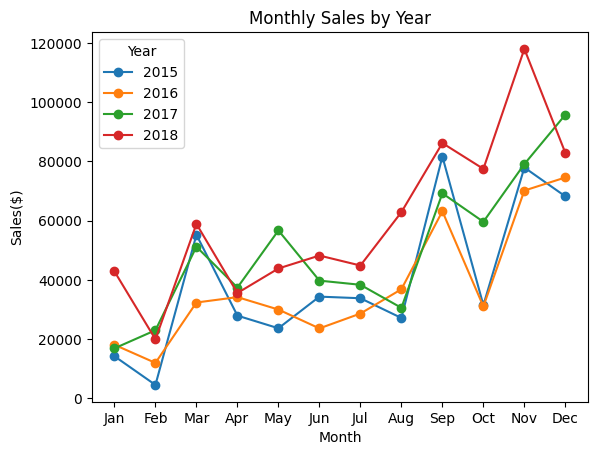

<Figure size 640x480 with 0 Axes>

In [6]:
#Aggregating sum of the monthly and weekly sales 
monthly_sales = df.groupby(["Month","Year"])["Sales($)"].sum()  
print(monthly_sales)
weekly_sales = df.groupby(["Day of Week"])["Sales($)"].sum()
weekly_sales
#for finding which prduct category has the highest revenue
highest_revenue_category = df.groupby("Category")["Sales($)"].sum()
print("The highest revenue category is:", highest_revenue_category.idxmax()) 
#idxmax() returns the index of the first occurrence of the maximum value in the Series. In this case, it will return the category with the highest revenue.

#for finding the region having the most consistent sales growth in past four years
consitent_sales_growth = df.groupby(["Region","Year"])["Sales($)"].sum().pct_change().groupby("Region").mean()
print("The region with the most consistent sales growth is:", consitent_sales_growth.idxmax())

#for calculating the average shipping time for each shipping mode
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days
average_shipping_time = df.groupby(["Region"])["Shipping Time"].mean().to_frame().style.format("{:.2f} days")
print("The average shipping time for each region is:")
# average_shipping_time  # Formatting the output to show two decimal places and adding "days" to the output
#not able to display the average shipping by print statement as it is a Styler object. 
# To display the Styler object, we can use the display() function from IPython.display module.

display(average_shipping_time)

#checking the if there are months in which consistent spikes are present accross all years.
monthly_sales_by_year = df.groupby(["Year", "Month"])["Sales($)"].sum()
monthly_sales_by_year = monthly_sales_by_year.unstack(level=0) 
print("Monthly sales by year:")
display(monthly_sales_by_year)
plt.plot(monthly_sales_by_year,marker='o')
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.xticks(ticks=range(1, 13), labels=months)
plt.title("Monthly Sales by Year")
plt.xlabel("Month")
plt.ylabel("Sales($)")
plt.legend(monthly_sales_by_year.columns, title="Year")
plt.show()
plt.savefig("monthly_sales_by_year.png")

In [7]:
"""According to the analysis, answers can made to the following questions:
 ○	Which product category generates the highest total revenue?
Ans : Technology category generates the highest total revenue.

○	Which region has the most consistent sales growth over 4 years?
Ans : The region with the most consistent sales growth is the West region.
○	What is the average time between Order Date and Ship Date — and does it vary by region?
Ans : The average shipping time for each region is:
    Central	4.07 days
    East	3.91 days
    South	3.96 days
    West	3.93 days
    It is observed that the average shipping time varies slightly by region.
○	Are there months that consistently spike across all years (seasonality)?
Ans: Yes, there are months that constitently spike across all years.
    Feb, March, Sep and Oct are the months that consistently spike across all years.
    The graph is given with the analysis refer to that for more details.
"""


'According to the analysis, answers can made to the following questions:\n ○\tWhich product category generates the highest total revenue?\nAns : Technology category generates the highest total revenue.\n\n○\tWhich region has the most consistent sales growth over 4 years?\nAns : The region with the most consistent sales growth is the West region.\n○\tWhat is the average time between Order Date and Ship Date — and does it vary by region?\nAns : The average shipping time for each region is:\n    Central\t4.07 days\n    East\t3.91 days\n    South\t3.96 days\n    West\t3.93 days\n    It is observed that the average shipping time varies slightly by region.\n○\tAre there months that consistently spike across all years (seasonality)?\nAns: Yes, there are months that constitently spike across all years.\n    Feb, March, Sep and Oct are the months that consistently spike across all years.\n    The graph is given with the analysis refer to that for more details.\n'

Date
2015-01-01     14205.7070
2015-02-01      4519.8920
2015-03-01     55205.7970
2015-04-01     27906.8550
2015-05-01     23644.3030
2015-06-01     34322.9356
2015-07-01     33781.5430
2015-08-01     27117.5365
2015-09-01     81623.5268
2015-10-01     31453.3930
2015-11-01     77907.6607
2015-12-01     68167.0585
2016-01-01     18066.9576
2016-02-01     11951.4110
2016-03-01     32339.3184
2016-04-01     34154.4685
2016-05-01     29959.5305
2016-06-01     23599.3740
2016-07-01     28608.2590
2016-08-01     36818.3422
2016-09-01     63133.6060
2016-10-01     31011.7375
2016-11-01     70129.2995
2016-12-01     74543.6012
2017-01-01     16870.1810
2017-02-01     22978.8150
2017-03-01     51165.0590
2017-04-01     37385.0170
2017-05-01     56656.9080
2017-06-01     39724.4860
2017-07-01     38320.7830
2017-08-01     30542.2003
2017-09-01     69193.3909
2017-10-01     59583.0330
2017-11-01     79066.4958
2017-12-01     95739.1210
2018-01-01     42839.2940
2018-02-01     19920.9974
2018-03

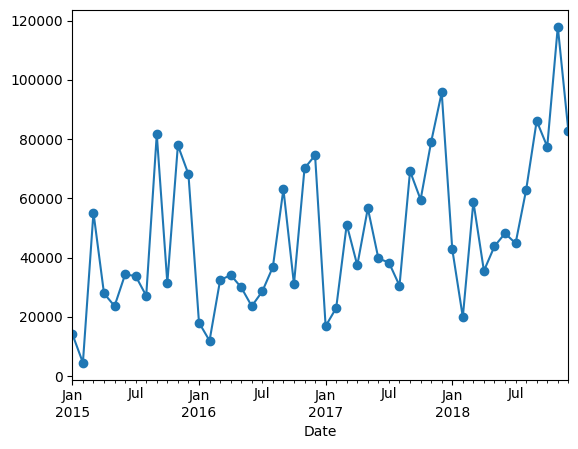

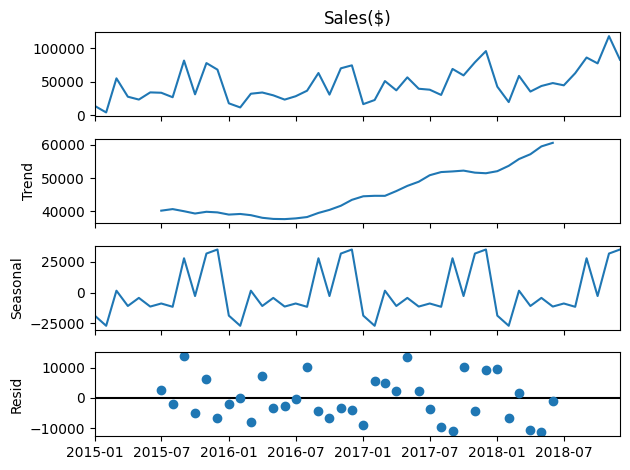

<Figure size 640x480 with 0 Axes>

In [8]:
#To apply time series decompostion (using statsmodels) to check for seasonality, trend and residuals.
import statsmodels.tsa.seasonal as seasonal
#To construct overall 4 years monthly sales data and check for seasonality, trend and residuals.
# monthly_sales_by_year2 = df.groupby(["Month"])["Sales($)"].sum()
monthly_sales_by_year2= (
    df.groupby(['Year', 'Month'])['Sales($)']
      .sum()
      .reset_index()
)

monthly_sales_by_year2["Date"] =  pd.to_datetime(
    monthly_sales_by_year2['Year'].astype(str) + '-' +
    monthly_sales_by_year2['Month'].astype(str)
)
monthly_sales_by_year2 = (
    monthly_sales_by_year2
    .sort_values('Date')
    .set_index('Date')['Sales($)']
) #this changes dataframe to series with date as index and sales as values. This is required for seasonal decomposition.

monthly_sales_by_year2.plot(marker='o')
display(monthly_sales_by_year2)
result = seasonal.seasonal_decompose(monthly_sales_by_year2, model='additive',period=12) #checking period as yearly
result.plot()

plt.show()
plt.savefig("seasonal_decompose.png")

In [9]:
"""
1. Trend
The trend component indicates an overall upward trend in monthly sales from 2015 to 2018.
There is a slight decline or flattening during early 2016, after which the trend increases steadily.
The increasing trend suggests that the average monthly sales improved over the four-year period, reflecting sustained business growth.

2. Seasonality
The seasonal component exhibits a strong annual seasonal pattern, with the same monthly effects repeating every 12 months.
Certain months consistently have positive seasonal effects, where sales are above the long-term trend, while other months consistently show negative seasonal effects, where sales are below the trend.
The seasonal variation ranges approximately from −30,000 to +30,000, indicating that seasonality has a substantial influence on monthly sales.

3. Residual (Random Noise)
The residual component fluctuates randomly around zero, indicating that the trend and seasonal components have explained most of the systematic variation in the data.
Most residual values lie within approximately −12,000 to +15,000.
A few months show relatively larger positive or negative residuals, suggesting occasional unexpected events (such as promotions, holidays, supply issues, or unusual customer demand) that are not explained by the trend or seasonality.
Since there is no clear pattern in the residuals, they can be regarded as random noise, which is desirable in a well-fitted decomposition model.
"""



'\n1. Trend\nThe trend component indicates an overall upward trend in monthly sales from 2015 to 2018.\nThere is a slight decline or flattening during early 2016, after which the trend increases steadily.\nThe increasing trend suggests that the average monthly sales improved over the four-year period, reflecting sustained business growth.\n\n2. Seasonality\nThe seasonal component exhibits a strong annual seasonal pattern, with the same monthly effects repeating every 12 months.\nCertain months consistently have positive seasonal effects, where sales are above the long-term trend, while other months consistently show negative seasonal effects, where sales are below the trend.\nThe seasonal variation ranges approximately from −30,000 to +30,000, indicating that seasonality has a substantial influence on monthly sales.\n\n3. Residual (Random Noise)\nThe residual component fluctuates randomly around zero, indicating that the trend and seasonal components have explained most of the systemat

In [10]:
#For checking stationarity of the time series data, we can use the Augmented Dickey-Fuller (ADF) test. 
# The null hypothesis of the ADF test is that the time series has a unit root, meaning it is non-stationary.
# If the p-value is less than a significance level (commonly 0.05), 
# we reject the null hypothesis and conclude that the time series is stationary.
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


result = adfuller(monthly_sales_by_year2)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value:.3f}")

ADF Statistic: -4.424951605714014
p-value: 0.00026806297280114596

Critical Values:
1%: -3.578
5%: -2.925
10%: -2.601


In [11]:
"""
The Augmented Dickey-Fuller (ADF) test was conducted to evaluate the stationarity of the monthly sales series. 
The test returned an ADF statistic of -4.425 and a p-value of 0.000268. Since the p-value is less than the significance 
level of 0.05, the null hypothesis of a unit root is rejected. Furthermore, the ADF statistic is more negative than the 
critical values at the 1%, 5%, and 10% significance levels, confirming that the series is stationary.
 Therefore, the time series satisfies the stationarity assumption and is appropriate for further forecasting analysis 
 without additional differencing.
"""

'\nThe Augmented Dickey-Fuller (ADF) test was conducted to evaluate the stationarity of the monthly sales series. \nThe test returned an ADF statistic of -4.425 and a p-value of 0.000268. Since the p-value is less than the significance \nlevel of 0.05, the null hypothesis of a unit root is rejected. Furthermore, the ADF statistic is more negative than the \ncritical values at the 1%, 5%, and 10% significance levels, confirming that the series is stationary.\n Therefore, the time series satisfies the stationarity assumption and is appropriate for further forecasting analysis \n without additional differencing.\n'

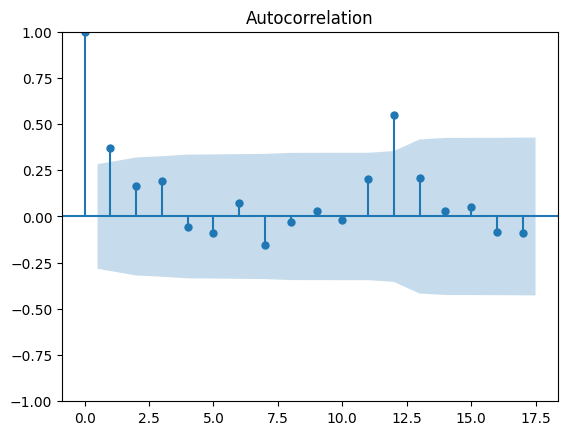

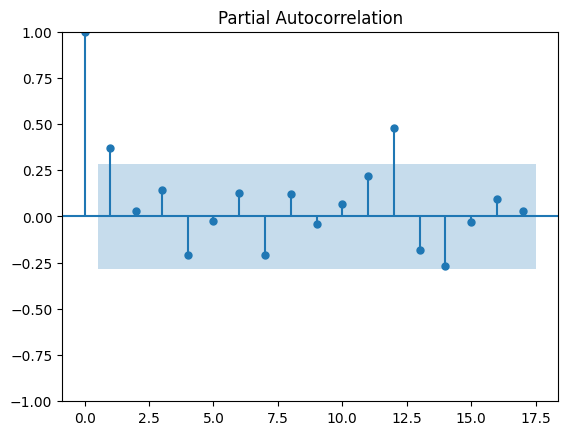

"\nThe ACF plot shows significant positive autocorrelation at lag 1 and lag 12. The lag-1 spike indicates that monthly sales\nare influenced by the previous month's sales, while the pronounced spike at lag 12 indicates a strong annual seasonal\npattern, where sales in a given month are correlated with sales in the same month of the previous year.\n\nThe PACF plot also shows significant spikes at lag 1 and lag 12, suggesting direct relationships with the immediately\npreceding month and the corresponding month in the previous year after accounting for intermediate lags. Most other lags \nfall within the 95% confidence interval, indicating that they do not contribute significantly to the dependence structure \nof the series.\n"

<Figure size 640x480 with 0 Axes>

In [60]:
plot_acf(monthly_sales_by_year2)
plot_pacf(monthly_sales_by_year2)

plt.show()
plt.savefig("acf_pacf.png")
"""
The ACF plot shows significant positive autocorrelation at lag 1 and lag 12. The lag-1 spike indicates that monthly sales
are influenced by the previous month's sales, while the pronounced spike at lag 12 indicates a strong annual seasonal
pattern, where sales in a given month are correlated with sales in the same month of the previous year.

The PACF plot also shows significant spikes at lag 1 and lag 12, suggesting direct relationships with the immediately
preceding month and the corresponding month in the previous year after accounting for intermediate lags. Most other lags 
fall within the 95% confidence interval, indicating that they do not contribute significantly to the dependence structure 
of the series.
"""

C:\Users\OK\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\OK\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\OK\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA Forecast Results:


,Month Ahead,Forecast Date,Actual Sales($),Predicted Sales($)
0,1,2018-10-01,77448.1312,65936.245349
1,2,2018-11-01,117938.1550,91073.662050
2,3,2018-12-01,82825.3588,100222.729966


RMSE: 19637.49
MAE: 18591.25
MAPE: 19.55%
Confidence Intervals for the forecasted sales:


,lower Sales($),upper Sales($)
2018-10-01,39530.332036,92342.158663
2018-11-01,59299.568930,122847.755170
2018-12-01,65986.616168,134458.843764


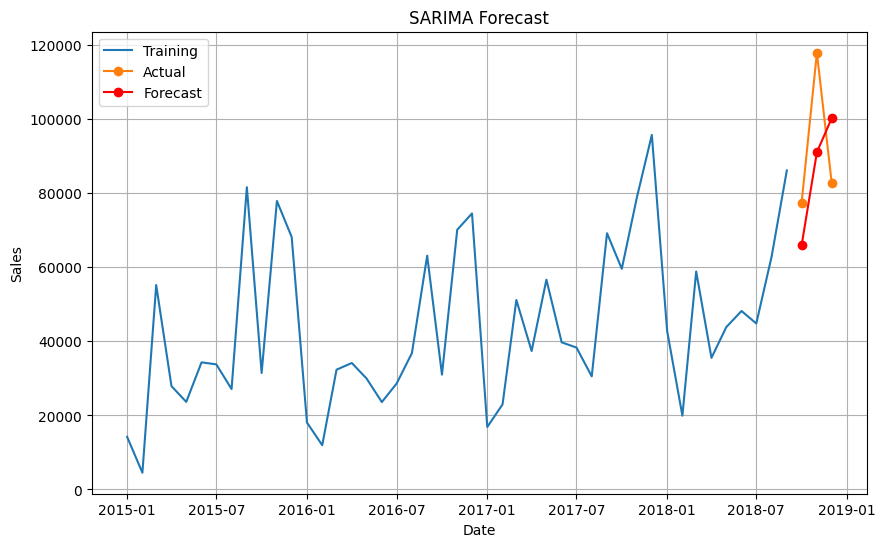

C:\Users\OK\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\OK\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\OK\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Next 3 Months SARIMA Forecast:


,Month Ahead,Forecast Date,Predicted Sales($)
0,1,2019-01-01,42796.306282
1,2,2019-02-01,34871.333082
2,3,2019-03-01,70029.328739


Confidence Intervals for the next 3 months:


,lower Sales($),upper Sales($)
2019-01-01,13077.714782,72514.897783
2019-02-01,125.921511,69616.744652
2019-03-01,33247.211069,106811.446409


<Figure size 640x480 with 0 Axes>

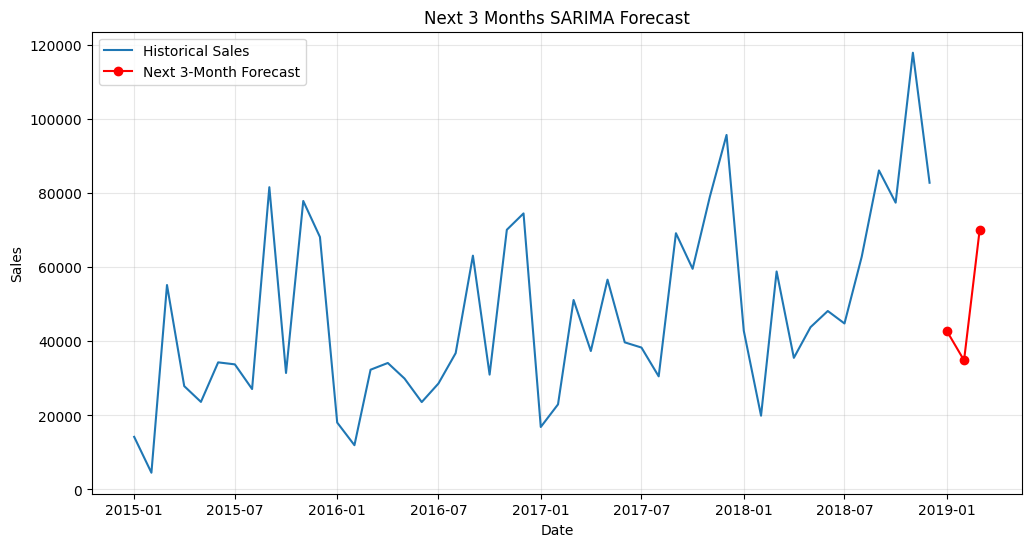

<Figure size 640x480 with 0 Axes>

In [61]:
#Training a SARIMA model for forecasting monthly sales for the next 3 months.
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

forecast_periods = 3
train_series = monthly_sales_by_year2.iloc[:-forecast_periods]
test_series = monthly_sales_by_year2.iloc[-forecast_periods:]

p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

model = SARIMAX(train_series, order=(p, d, q), seasonal_order=(P, D, Q, s))
# MS as frequency is monthly , pandas automatically infers the frequency from the datetime index,
#  so we don't need to specify it explicitly.
results = model.fit(disp=False)
forecast = results.get_forecast(steps=forecast_periods)
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

rmse = root_mean_squared_error(test_series, forecast_values)
mae = mean_absolute_error(test_series, forecast_values)
mape = mean_absolute_percentage_error(test_series, forecast_values) * 100

forecast_results = pd.DataFrame({
    "Month Ahead": [1, 2, 3],
    "Forecast Date": forecast_values.index,
    "Actual Sales($)": test_series.values,
    "Predicted Sales($)": forecast_values.values,
})

#for measuring efficiency of the model
print("SARIMA Forecast Results:")
display(forecast_results)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print("Confidence Intervals for the forecasted sales:")
display(confidence_intervals)

plt.figure(figsize=(10, 6))
plt.plot(train_series.index, train_series, label='Training')
plt.plot(test_series.index, test_series, label='Actual', marker='o')
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='red', marker='o')
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()
plt.savefig("sales_prediction_sarima.png")

# Forecast the next 3 months beyond the available dataset.
full_model = SARIMAX(monthly_sales_by_year2, order=(p, d, q), seasonal_order=(P, D, Q, s))
full_results = full_model.fit(disp=False)
future_forecast = full_results.get_forecast(steps=forecast_periods)
future_forecast_values = future_forecast.predicted_mean
future_confidence_intervals = future_forecast.conf_int()

future_forecast_results = pd.DataFrame({
    "Month Ahead": [1, 2, 3],
    "Forecast Date": future_forecast_values.index,
    "Predicted Sales($)": future_forecast_values.values,
})

print("Next 3 Months SARIMA Forecast:")
display(future_forecast_results)
print("Confidence Intervals for the next 3 months:")
display(future_confidence_intervals)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_by_year2.index, monthly_sales_by_year2.values, label='Historical Sales')
plt.plot(future_forecast_values.index, future_forecast_values.values, marker='o', color='red', label='Next 3-Month Forecast')
plt.title("Next 3 Months SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig("next_3_months_forecast_sarima.png")

19:48:11 - cmdstanpy - INFO - Chain [1] start processing
19:48:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecast Results:


,Month_Ahead,ds,Actual_Sales,yhat,yhat_lower,yhat_upper
45,1,2018-10-01,77448.1312,50763.090703,42096.547487,59277.552890
46,2,2018-11-01,117938.1550,88937.872456,80700.066437,97095.323868
47,3,2018-12-01,82825.3588,89293.684311,81018.001588,97255.744976


RMSE: 23057.52
MAE: 20717.88
MAPE: 22.28%


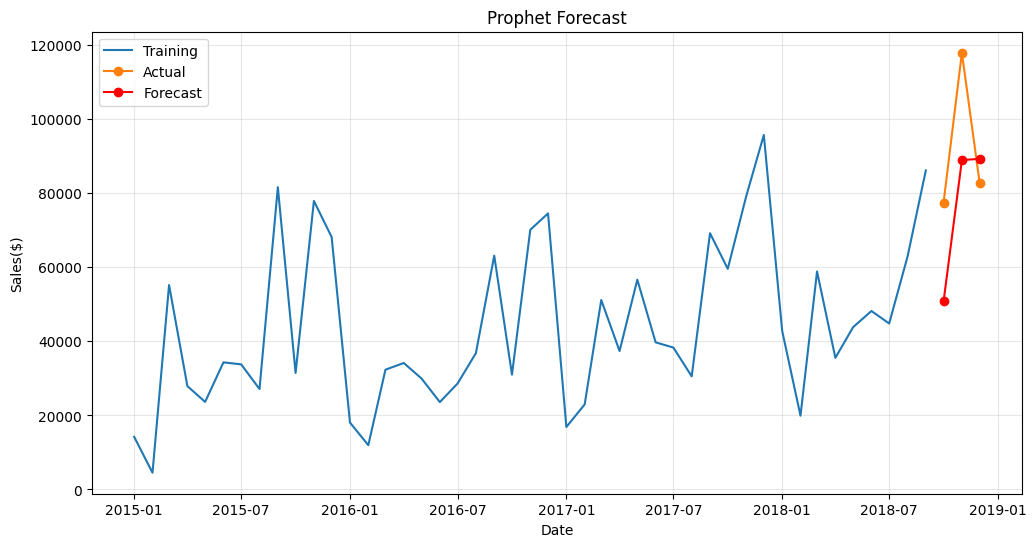

19:48:16 - cmdstanpy - INFO - Chain [1] start processing
19:48:18 - cmdstanpy - INFO - Chain [1] done processing


Next 3 Months Prophet Forecast:


,Month_Ahead,ds,yhat,yhat_lower,yhat_upper
48,1,2019-01-01,42327.931178,32778.092574,51624.710473
49,2,2019-02-01,33497.296590,24199.119728,42948.783327
50,3,2019-03-01,80422.682351,71177.895557,90006.449646


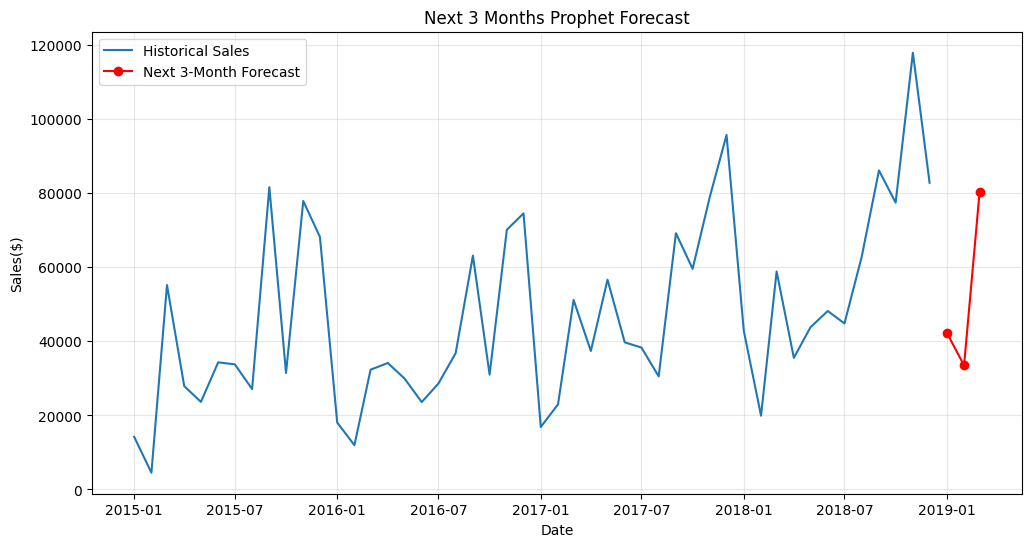

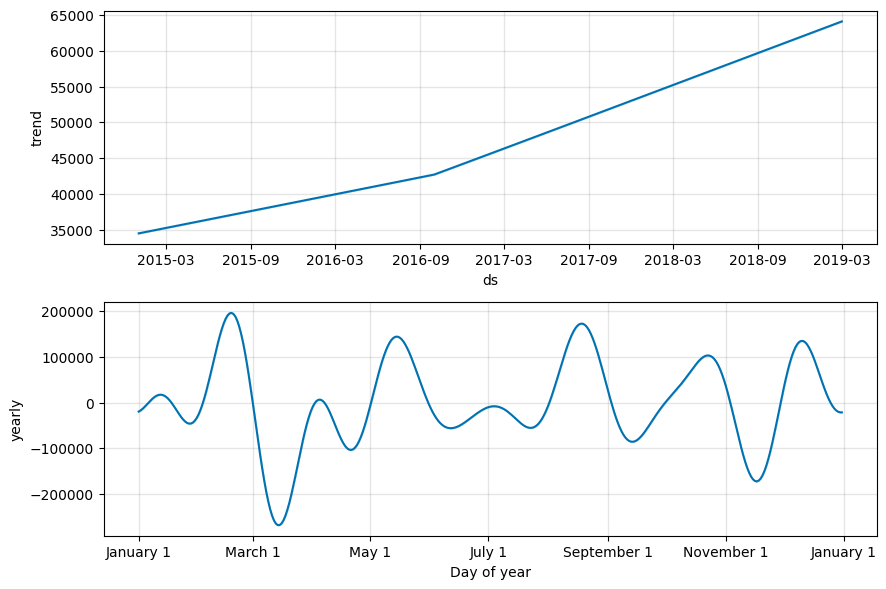

In [ ]:
from prophet import Prophet
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

forecast_periods = 3
prophet_train = monthly_sales_by_year2.iloc[:-forecast_periods]
prophet_test = monthly_sales_by_year2.iloc[-forecast_periods:]

# Prepare data
df_prophet = prophet_train.reset_index().rename(
    columns={'Date': 'ds', 'Sales($)': 'y'}
)

# Fit model
model = Prophet()
model.fit(df_prophet)

# Forecast next 3 months on the holdout period for evaluation.
future = model.make_future_dataframe(periods=forecast_periods, freq='MS')
forecast = model.predict(future)
#yhat - predicted values, yhat_lower - lower bound of the prediction interval, 
# yhat_upper - upper bound of the prediction interval
forecast_results = (
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    .tail(forecast_periods)
    .assign(
        Month_Ahead=[1, 2, 3],
        Actual_Sales=[float(value) for value in prophet_test.values],
    )
    [['Month_Ahead', 'ds', 'Actual_Sales', 'yhat', 'yhat_lower', 'yhat_upper']]
 )

rmse = root_mean_squared_error(prophet_test, forecast_results['yhat'])
mae = mean_absolute_error(prophet_test, forecast_results['yhat'])
mape = mean_absolute_percentage_error(prophet_test, forecast_results['yhat']) * 100

print("Prophet Forecast Results:")
display(forecast_results)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(prophet_train.index, prophet_train.values, label='Training')
plt.plot(prophet_test.index, prophet_test.values, marker='o', label='Actual')
plt.plot(forecast_results['ds'], forecast_results['yhat'], marker='o', label='Forecast', color='red')
plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Forecast the next 3 months beyond the available dataset.
prophet_full_df = monthly_sales_by_year2.reset_index().rename(
    columns={'Date': 'ds', 'Sales($)': 'y'}
)
prophet_full_model = Prophet()
prophet_full_model.fit(prophet_full_df)

future_full = prophet_full_model.make_future_dataframe(periods=forecast_periods, freq='MS')
future_full_forecast = prophet_full_model.predict(future_full)

future_forecast_results = (
    future_full_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    .tail(forecast_periods)
    .assign(Month_Ahead=[1, 2, 3])
    [['Month_Ahead', 'ds', 'yhat', 'yhat_lower', 'yhat_upper']]
 )

print("Next 3 Months Prophet Forecast:")
display(future_forecast_results)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_by_year2.index, monthly_sales_by_year2.values, label='Historical Sales')
plt.plot(future_forecast_results['ds'], future_forecast_results['yhat'], marker='o', color='red', label='Next 3-Month Forecast')
plt.title("Next 3 Months Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot trend and seasonality
prophet_full_model.plot_components(future_full_forecast)
plt.savefig("prophet_forecast_components.png")

XGBoost Forecast Results (Holdout):


,Actual Sales($),Predicted Sales($)
Date,,
2018-10-01,77448.1312,69025.335938
2018-11-01,117938.1550,86001.156250
2018-12-01,82825.3588,72793.945312


RMSE: 19929.41
MAE: 16797.07
MAPE: 16.69%


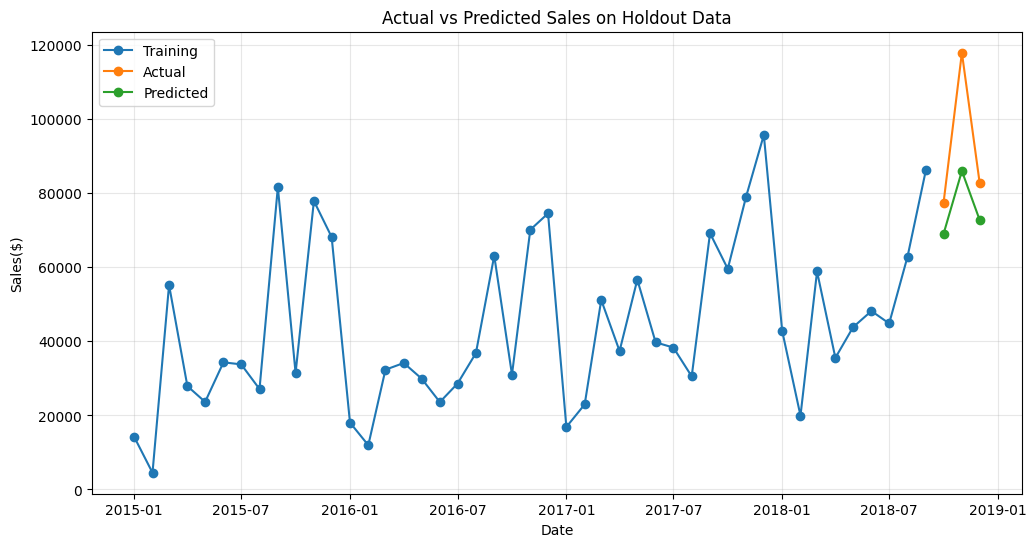

Next 3 Months Forecast:


,Predicted Sales($)
Date,
2019-01-01,41565.554688
2019-02-01,23574.548828
2019-03-01,48950.796875


<Figure size 640x480 with 0 Axes>

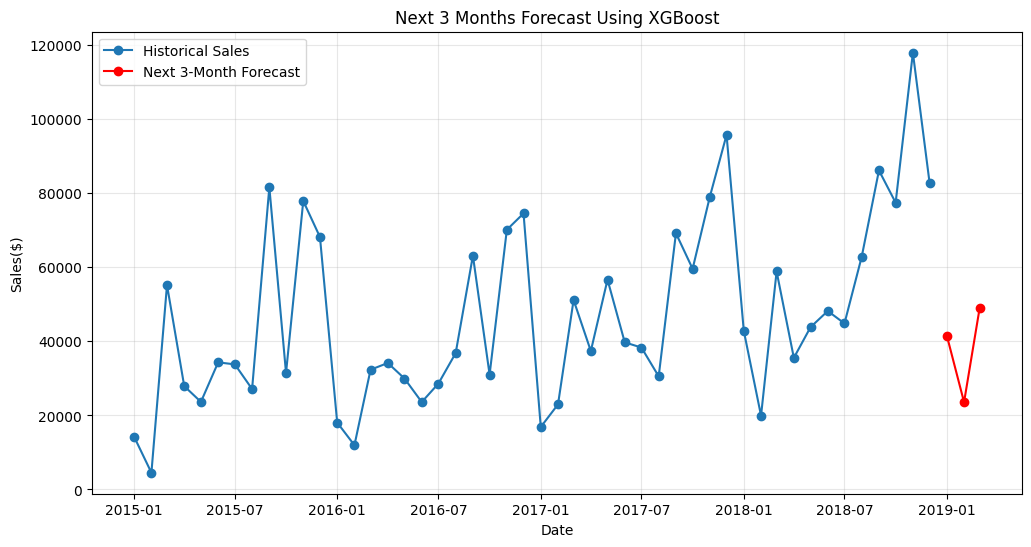

<Figure size 640x480 with 0 Axes>

In [62]:
# Convert monthly sales into a supervised learning dataset with lag features.
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

season_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"}

def build_feature_frame(series):
    frame = series.to_frame(name="y").copy()
    frame["Lag 1"] = frame["y"].shift(1)
    frame["Lag 2"] = frame["y"].shift(2)
    frame["Lag 3"] = frame["y"].shift(3)
    frame["Rolling Mean 3"] = frame["y"].shift(1).rolling(window=3).mean()
    frame["Month"] = frame.index.month
    frame["Quarter"] = frame.index.quarter
    frame["Season"] = frame["Month"].map(season_map)
    frame = pd.get_dummies(frame, columns=["Season"], drop_first=False)
    return frame.dropna()

forecast_periods = 3
train_series = monthly_sales_by_year2.iloc[:-forecast_periods]
test_series = monthly_sales_by_year2.iloc[-forecast_periods:]

train_feature_frame = build_feature_frame(train_series)
feature_columns = [column for column in train_feature_frame.columns if column != "y"]

X_train = train_feature_frame[feature_columns]
y_train = train_feature_frame["y"]

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)
model.fit(X_train, y_train)

# Recursively forecast the last 3 observed months for evaluation.
future_predictions = []
working_series = train_series.copy()

for next_date, actual_value in test_series.items():
    next_row = pd.DataFrame(index=[next_date])
    next_row["y"] = pd.NA
    next_row["Lag 1"] = working_series.iloc[-1]
    next_row["Lag 2"] = working_series.iloc[-2]
    next_row["Lag 3"] = working_series.iloc[-3]
    next_row["Rolling Mean 3"] = working_series.iloc[-3:].mean()
    next_row["Month"] = next_date.month
    next_row["Quarter"] = next_date.quarter
    next_row["Season"] = season_map[next_date.month]
    next_row = pd.get_dummies(next_row, columns=["Season"], drop_first=False)
    next_row = next_row.reindex(columns=train_feature_frame.columns, fill_value=0)

    next_pred = float(model.predict(next_row[feature_columns])[0])
    future_predictions.append((next_date, actual_value, next_pred))
    working_series.loc[next_date] = next_pred

forecast_df = pd.DataFrame(
    future_predictions,
    columns=["Date", "Actual Sales($)", "Predicted Sales($)"],
).set_index("Date")

rmse = root_mean_squared_error(forecast_df["Actual Sales($)"], forecast_df["Predicted Sales($)"])
mae = mean_absolute_error(forecast_df["Actual Sales($)"], forecast_df["Predicted Sales($)"])
mape = mean_absolute_percentage_error(forecast_df["Actual Sales($)"], forecast_df["Predicted Sales($)"]) * 100

print("XGBoost Forecast Results (Holdout):")
display(forecast_df)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series.values, marker="o", label="Training")
plt.plot(forecast_df.index, forecast_df["Actual Sales($)"], marker="o", label="Actual")
plt.plot(forecast_df.index, forecast_df["Predicted Sales($)"], marker="o", label="Predicted")
plt.title("Actual vs Predicted Sales on Holdout Data")
plt.xlabel("Date")
plt.ylabel("Sales($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig("sales_prediction_xgboost.png")
# Predict the next 3 months beyond the available dataset using recursive forecasting.
future_horizon = 3
future_predictions_next = []
future_series = monthly_sales_by_year2.copy()
last_date = future_series.index.max()

for i in range(future_horizon):
    next_date = last_date + pd.DateOffset(months=1)
    next_row = pd.DataFrame(index=[next_date])
    next_row["y"] = pd.NA
    next_row["Lag 1"] = future_series.iloc[-1]
    next_row["Lag 2"] = future_series.iloc[-2]
    next_row["Lag 3"] = future_series.iloc[-3]
    next_row["Rolling Mean 3"] = future_series.iloc[-3:].mean()
    next_row["Month"] = next_date.month
    next_row["Quarter"] = next_date.quarter
    next_row["Season"] = season_map[next_date.month]
    next_row = pd.get_dummies(next_row, columns=["Season"], drop_first=False)
    next_row = next_row.reindex(columns=train_feature_frame.columns, fill_value=0)

    next_pred = float(model.predict(next_row[feature_columns])[0])
    future_predictions_next.append((next_date, next_pred))
    future_series.loc[next_date] = next_pred
    last_date = next_date

future_forecast_df = pd.DataFrame(
    future_predictions_next,
    columns=["Date", "Predicted Sales($)"],
).set_index("Date")

print("Next 3 Months Forecast:")
display(future_forecast_df)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_by_year2.index, monthly_sales_by_year2.values, marker="o", label="Historical Sales")
plt.plot(future_forecast_df.index, future_forecast_df["Predicted Sales($)"], marker="o", color="red", label="Next 3-Month Forecast")
plt.title("Next 3 Months Forecast Using XGBoost")
plt.xlabel("Date")
plt.ylabel("Sales($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig("next_3_months_forecast_xgboost.png")

In [ ]:
"""
Model	        MAE            RMSE	            MAPE	        Forecast for Month 1	        Forecast for Month 2	    Forecast for Month 3

SARIMA		   19637.49	       18591.25		    19.55%              42796.306282                    34871.333082                70029.328739

Prophet		   23057.52		   23057.52         22.28%              42327.931178                    33497.296590                 80422.682351

XGBoost		   19929.41		    16797.07        16.69%              41565.554688                    23574.548828                 48950.796875


By the above observation, i will be choosing XGBoost model for forecasting the next 3 months 
as it has the lowest RMSE and MAPE values compared to SARIMA and Prophet models.
"""

'\nModel\t        MAE            RMSE\t            MAPE\t        Forecast for Month 1\t        Forecast for Month 2\t    Forecast for Month 3\n\nSARIMA\t\t   19637.49\t       18591.25\t\t    19.55%              42796.306282                    34871.333082                70029.328739\n\nProphet\t\t   23057.52\t\t   23057.52         22.28%              42327.931178                    33497.296590                 80422.682351\n\nXGBoost\t\t   19929.41\t\t    16797.07        16.69%              41565.554688                    23574.548828                 48950.796875\n\n'

Furniture Category Sales - Next 3 Months Forecast:


,Predicted Sales($)
Date,
2019-01-01,6538.755859
2019-02-01,6736.211914
2019-03-01,12177.053711


Technology Category Sales - Next 3 Months Forecast:


,Predicted Sales($)
Date,
2019-01-01,16136.951172
2019-02-01,19613.845703
2019-03-01,18301.810547


Office Supplies Category Sales - Next 3 Months Forecast:


,Predicted Sales($)
Date,
2019-01-01,15213.616211
2019-02-01,9819.559570
2019-03-01,19557.068359


West Region Sales - Next 3 Months Forecast:


,Predicted Sales($)
Date,
2019-01-01,10564.001953
2019-02-01,13591.239258
2019-03-01,19730.578125


East Region Sales - Next 3 Months Forecast:


,Predicted Sales($)
Date,
2019-01-01,8721.672852
2019-02-01,8021.555664
2019-03-01,8393.420898


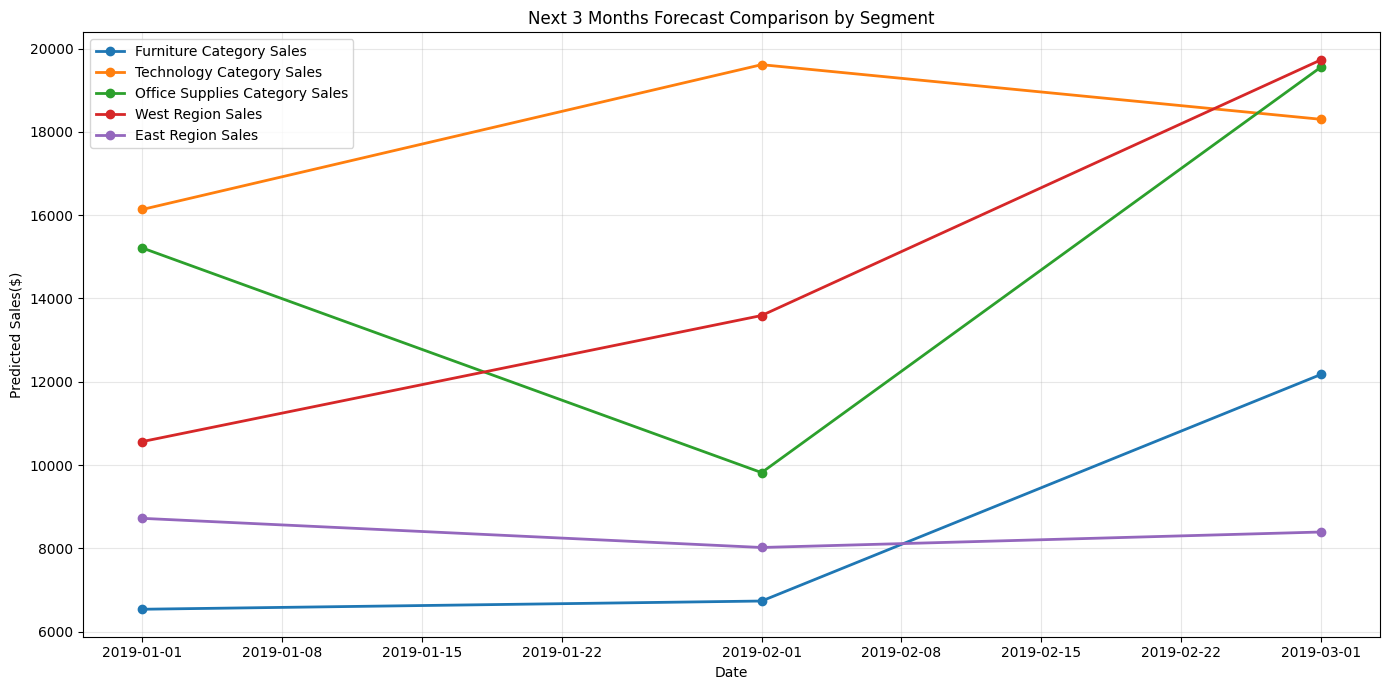

<Figure size 640x480 with 0 Axes>

In [63]:
# Repeat the best performing model (XGBoost) separately for each requested segment.

season_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"}

def build_feature_frame(series):
    frame = series.to_frame(name="y").copy()
    frame["Lag 1"] = frame["y"].shift(1)
    frame["Lag 2"] = frame["y"].shift(2)
    frame["Lag 3"] = frame["y"].shift(3)
    frame["Rolling Mean 3"] = frame["y"].shift(1).rolling(window=3).mean()
    frame["Month"] = frame.index.month
    frame["Quarter"] = frame.index.quarter
    frame["Season"] = frame["Month"].map(season_map)
    frame = pd.get_dummies(frame, columns=["Season"], drop_first=False)
    return frame.dropna()


def forecast_segment_sales(segment_df, horizon=3):
    segment_series = (
        segment_df.set_index("Order Date")["Sales($)"]
        .resample("MS")
        .sum()
        .asfreq("MS")
        .fillna(0)
    )

    train_frame = build_feature_frame(segment_series)
    feature_columns = [column for column in train_frame.columns if column != "y"]

    segment_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
    )
    segment_model.fit(train_frame[feature_columns], train_frame["y"])

    future_predictions = []
    working_series = segment_series.copy()
    last_date = working_series.index.max()

    for _ in range(horizon):
        next_date = last_date + pd.DateOffset(months=1)
        next_row = pd.DataFrame(index=[next_date])
        next_row["y"] = pd.NA
        next_row["Lag 1"] = working_series.iloc[-1]
        next_row["Lag 2"] = working_series.iloc[-2]
        next_row["Lag 3"] = working_series.iloc[-3]
        next_row["Rolling Mean 3"] = working_series.iloc[-3:].mean()
        next_row["Month"] = next_date.month
        next_row["Quarter"] = next_date.quarter
        next_row["Season"] = season_map[next_date.month]
        next_row = pd.get_dummies(next_row, columns=["Season"], drop_first=False)
        next_row = next_row.reindex(columns=train_frame.columns, fill_value=0)

        next_pred = float(segment_model.predict(next_row[feature_columns])[0])
        future_predictions.append((next_date, next_pred))
        working_series.loc[next_date] = next_pred
        last_date = next_date

    return pd.DataFrame(future_predictions, columns=["Date", "Predicted Sales($)"]).set_index("Date")


segment_series_map = {
    "Furniture Category Sales": df[df["Category"] == "Furniture"],
    "Technology Category Sales": df[df["Category"] == "Technology"],
    "Office Supplies Category Sales": df[df["Category"] == "Office Supplies"],
    "West Region Sales": df[df["Region"] == "West"],
    "East Region Sales": df[df["Region"] == "East"],
}

segment_forecasts = {}
for segment_name, segment_frame in segment_series_map.items():
    segment_forecasts[segment_name] = forecast_segment_sales(segment_frame, horizon=3)
    print(f"{segment_name} - Next 3 Months Forecast:")
    display(segment_forecasts[segment_name])

comparison_chart = pd.DataFrame(index=segment_forecasts[next(iter(segment_forecasts))].index)
for segment_name, forecast_frame in segment_forecasts.items():
    comparison_chart[segment_name] = forecast_frame["Predicted Sales($)"]

plt.figure(figsize=(14, 7))
for column in comparison_chart.columns:
    plt.plot(comparison_chart.index, comparison_chart[column], marker="o", linewidth=2, label=column)

plt.title("Next 3 Months Forecast Comparison by Segment")
plt.xlabel("Date")
plt.ylabel("Predicted Sales($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig("next_3_months_forecast_comparison_segments.png")

In [28]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales($),Year,Month,Day,Day of Week,Quarter,Season,Shipping Time
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8,2,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8,2,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12,0,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11,1,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11,1,4,Autumn,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,...,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,2017,5,21,6,2,Spring,7
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,2016,1,12,1,1,Winter,5
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,Phones,GE 30524EE4,235.1880,2016,1,12,1,1,Winter,5
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,2016,1,12,1,1,Winter,5


Detected Anomalies in Sales Data (Isolation Forest):


,Order Date,Sales($)
0,2015-01-04,304.508
1,2015-02-22,224.912
2,2015-03-22,37703.665
3,2015-09-13,29959.137
4,2016-01-24,358.522
5,2017-10-08,28412.098
6,2017-11-26,27367.716
7,2017-12-17,25449.800
8,2018-11-04,29017.467
9,2018-11-18,30572.447


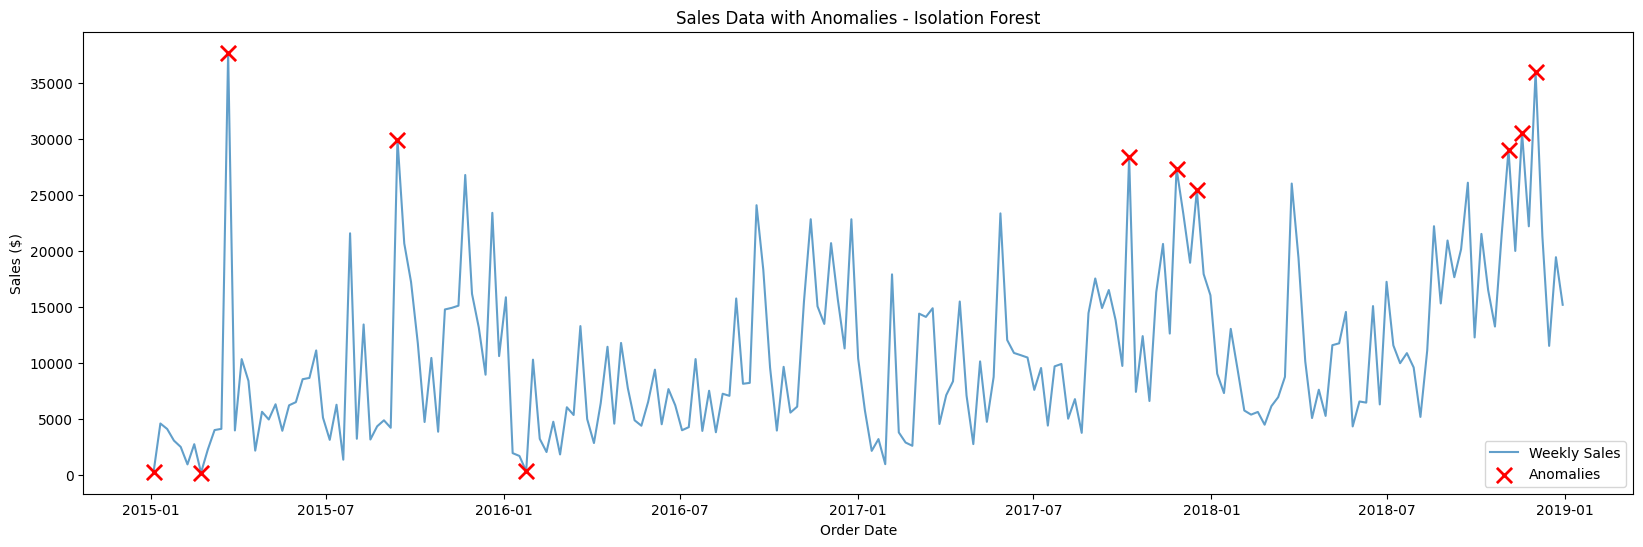

Detected Anomalies in Sales Data (Z-Score, rolling window = 4):


,Order Date,Sales($),Rolling Mean,Rolling Std,Z Score
5,2015-02-08,968.5340,3592.524750,953.362968,-2.752352
7,2015-02-22,224.9120,2340.011500,943.108457,-2.242690
9,2015-03-08,4030.7280,1563.535750,1173.495162,2.102431
11,2015-03-22,37703.6650,2671.221250,1837.972754,19.060372
22,2015-06-07,8569.9480,5766.387750,1204.728869,2.327130
24,2015-06-21,11139.4446,7504.611750,1301.478386,2.792849
26,2015-07-05,3158.4000,8384.157900,2464.041386,-2.120808
29,2015-07-26,21590.0800,3995.168000,2167.025645,8.119383
36,2015-09-13,29959.1370,4172.795625,717.144865,35.956949
46,2015-11-22,26793.6235,12185.782550,5536.913882,2.638264


<Figure size 640x480 with 0 Axes>

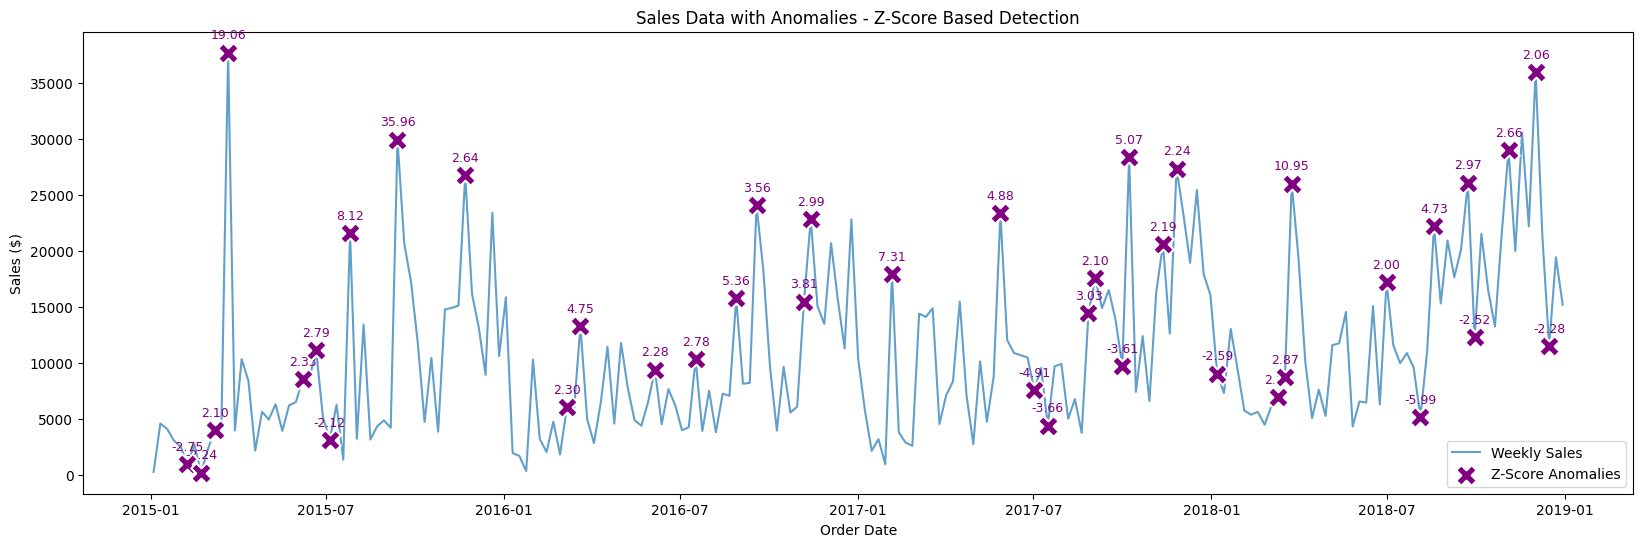

<Figure size 640x480 with 0 Axes>

In [56]:
# Task 5
# To detect anomalies in sales data.
from sklearn.ensemble import IsolationForest

weekly_sales = df.resample('W', on='Order Date')['Sales($)'].sum().reset_index()

iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_anomly = iso_model.fit_predict(weekly_sales[['Sales($)']])
anomalies = weekly_sales[iso_anomly == -1].reset_index(drop=True)

print("Detected Anomalies in Sales Data (Isolation Forest):")
display(anomalies[["Order Date", "Sales($)"]])

plt.figure(figsize=(20, 6))
plt.plot(weekly_sales['Order Date'], weekly_sales['Sales($)'], label='Weekly Sales', alpha=0.7)
plt.scatter(anomalies['Order Date'], anomalies['Sales($)'], color='red', label='Anomalies', marker='x', s=120, linewidths=2, zorder=5)
plt.xlabel('Order Date')
plt.ylabel('Sales ($)')
plt.title('Sales Data with Anomalies - Isolation Forest')
plt.legend()
plt.show()
plt.savefig("sales_anomalies_isolation_forest.png")

# Z-score based anomaly detection using a rolling mean and standard deviation.
rolling_window = 4
weekly_sales["Rolling Mean"] = weekly_sales["Sales($)"].shift(1).rolling(window=rolling_window, min_periods=rolling_window).mean()
weekly_sales["Rolling Std"] = weekly_sales["Sales($)"].shift(1).rolling(window=rolling_window, min_periods=rolling_window).std()
weekly_sales["Z Score"] = (weekly_sales["Sales($)"] - weekly_sales["Rolling Mean"]) / weekly_sales["Rolling Std"]

zscore_candidates = weekly_sales[weekly_sales["Rolling Std"].notna()].copy()
zscore_candidates["Abs Z Score"] = zscore_candidates["Z Score"].abs()
zscore_anomalies = zscore_candidates[zscore_candidates["Abs Z Score"] > 2].copy()

print("Detected Anomalies in Sales Data (Z-Score, rolling window = 4):")
if zscore_anomalies.empty:
    print("No weeks exceeded 2 standard deviations from the prior 4-week rolling mean.")
else:
    display(zscore_anomalies[["Order Date", "Sales($)", "Rolling Mean", "Rolling Std", "Z Score"]])

plt.figure(figsize=(20, 6))
plt.plot(weekly_sales['Order Date'], weekly_sales['Sales($)'], label='Weekly Sales', alpha=0.7)
if not zscore_anomalies.empty:
    plt.scatter(
        zscore_anomalies['Order Date'],
        zscore_anomalies['Sales($)'],
        color='purple',
        label='Z-Score Anomalies',
        marker='X',
        s=220,
        edgecolors='white',
        linewidths=1.5,
        zorder=10,
    )
    for _, row in zscore_anomalies.iterrows():
        plt.annotate(
            f"{row['Z Score']:.2f}",
            (row['Order Date'], row['Sales($)']),
            textcoords='offset points',
            xytext=(0, 10),
            ha='center',
            fontsize=9,
            color='purple',
        )
else:
    plt.text(
        0.5,
        0.95,
        'No Z-score anomalies found with the 2-sigma rule.',
        transform=plt.gca().transAxes,
        ha='center',
        va='top',
        fontsize=11,
        color='purple',
    )

plt.xlabel('Order Date')
plt.ylabel('Sales ($)')
plt.title('Sales Data with Anomalies - Z-Score Based Detection')
plt.legend()
plt.show()
plt.savefig("sales_anomalies_zscore.png")

In [ ]:
"""Isolation Forest identified several weeks with unusually high and low sales. 
High-sales anomalies are likely due to seasonal events, festive sales, promotional campaigns, 
or large bulk orders placed by customers. Low-sales anomalies may indicate store closures, inventory shortages,
 public holidays, technical issues in order processing, or missing/incomplete sales records.
 These anomalous weeks differ significantly from the normal weekly
 sales pattern and warrant further business investigation.
 
 Both methods detected the major anomalies, particularly the weeks with extremely high sales 
approximately $30,000–$37,000) and very low sales. However, the Z-Score method identified many
additional weeks as anomalous, whereas Isolation Forest detected only the most isolated observations.
This difference occurs because Z-Score relies on the statistical distance from the mean and assumes
 an approximately normal distribution, while Isolation Forest is a machine learning algorithm that
identifies anomalies based on how isolated observations are within the dataset. Therefore, Isolation 
 Forest is generally more robust for sales data containing skewness and irregular fluctuations, whereas
Z-Score is more sensitive and may produce a larger number of anomaly detections.
 
 """

,Total Sales Volume,Sales Volatility,Average Order Value,YoY Growth Rate (%)
Sub-Category,,,,
Phones,326487.70,4083.11,407.09,12.46
Chairs,322107.53,4387.62,570.10,7.22
Storage,217779.10,2856.35,285.42,13.03
Tables,202810.63,3224.08,671.56,16.41
Binders,200028.78,3848.22,154.94,21.87
Machines,189238.63,5389.83,1689.63,8.01
Accessories,163881.69,2578.70,234.12,37.50
Copiers,146248.09,4969.72,2215.88,84.67
Bookcases,109408.30,2092.02,495.06,19.59


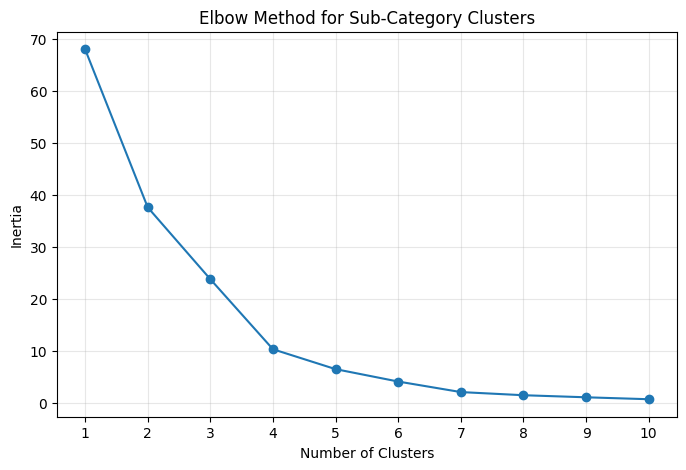

Using 4 clusters to match the requested demand archetypes.


,Total Sales Volume,YoY Growth Rate (%),Sales Volatility,Average Order Value
Cluster,,,,
0,238849.24,18.08,3496.35,387.21
1,54700.62,19.33,892.12,131.83
2,167743.36,46.34,5179.77,1952.76
3,46420.31,192.84,1959.29,256.47


,,Total Sales Volume,YoY Growth Rate (%),Sales Volatility,Average Order Value
Cluster,Cluster Label,,,,
0,"High Volume, Stable Demand",238849.24,18.08,3496.35,387.21
2,"High Volume, High Volatility",167743.36,46.34,5179.77,1952.76
1,"Low Volume, Stable Demand",54700.62,19.33,892.12,131.83
3,Growing Demand,46420.31,192.84,1959.29,256.47


,,Stocking Strategy
Cluster,Cluster Label,
0,"High Volume, Stable Demand","Keep higher on-hand inventory, use regular rep..."
2,"High Volume, High Volatility","Hold moderate safety stock, review frequently,..."
1,"Low Volume, Stable Demand","Use lean stock, small reorder quantities, and ..."
3,Growing Demand,"Increase reorder quantities early, build extra..."


<Figure size 640x480 with 0 Axes>

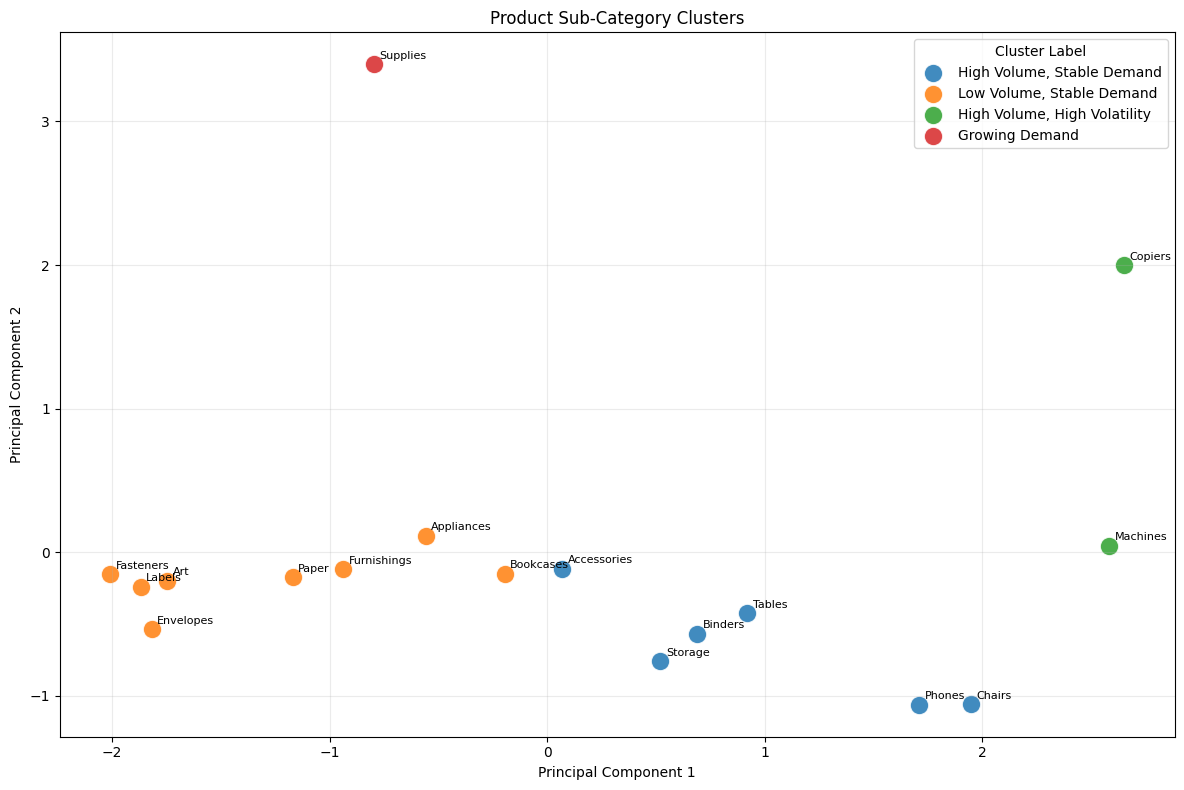

Recommended stocking strategy by cluster:
- Growing Demand: Increase reorder quantities early, build extra safety stock, and monitor trend acceleration closely.
- High Volume, Stable Demand: Keep higher on-hand inventory, use regular replenishment cycles, and avoid stockouts with a strong reorder point.
- Low Volume, Stable Demand: Use lean stock, small reorder quantities, and avoid overcommitting shelf space to slow movers.
- High Volume, High Volatility: Hold moderate safety stock, review frequently, and replenish in smaller batches to absorb demand swings.


<Figure size 640x480 with 0 Axes>

In [65]:
# Task 6 - Product sub-category clustering
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

subcat_monthly = (
    df.groupby(["Sub-Category", "Year", "Month"])["Sales($)"]
    .sum()
    .reset_index()
)
subcat_monthly["Date"] = pd.to_datetime(
    subcat_monthly["Year"].astype(str) + "-" + subcat_monthly["Month"].astype(str)
)

monthly_sales_pivot = subcat_monthly.pivot_table(
    index="Sub-Category",
    columns="Date",
    values="Sales($)",
    fill_value=0,
)

yearly_sales = (
    df.groupby(["Sub-Category", "Year"])["Sales($)"]
    .sum()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

subcat_features = pd.DataFrame(index=monthly_sales_pivot.index)
subcat_features["Total Sales Volume"] = (
    df.groupby("Sub-Category")["Sales($)"]
    .sum()
)
subcat_features["Sales Volatility"] = monthly_sales_pivot.std(axis=1)
subcat_features["Average Order Value"] = (
    df.groupby("Sub-Category")["Sales($)"]
    .sum()
    / df.groupby("Sub-Category")["Order ID"].nunique()
)
subcat_features["YoY Growth Rate (%)"] = (
    yearly_sales.pct_change(axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .mean(axis=1)
    .fillna(0)
    * 100
)
subcat_features = subcat_features.sort_values("Total Sales Volume", ascending=False)

display(subcat_features.round(2))

feature_columns = [
    "Total Sales Volume",
    "YoY Growth Rate (%)",
    "Sales Volatility",
    "Average Order Value",
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(subcat_features[feature_columns])

k_values = range(1, min(10, len(subcat_features)) + 1)
inertias = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for Sub-Category Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig("elbow_method_subcategory_clusters.png")

optimal_k = 4
print(f"Using {optimal_k} clusters to match the requested demand archetypes.")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat_features["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_summary = (
    subcat_features.groupby("Cluster")[feature_columns]
    .mean()
    .round(2)
)
display(cluster_summary)

cluster_label_map = {}
assigned_clusters = set()
cluster_summary_ordered = cluster_summary.copy()

growing_cluster = cluster_summary_ordered["YoY Growth Rate (%)"].idxmax()
cluster_label_map[growing_cluster] = "Growing Demand"
assigned_clusters.add(growing_cluster)

remaining_clusters = [cluster for cluster in cluster_summary_ordered.index if cluster not in assigned_clusters]
high_volume_stable_cluster = max(
    remaining_clusters,
    key=lambda cluster: (
        cluster_summary_ordered.loc[cluster, "Total Sales Volume"]
        - cluster_summary_ordered.loc[cluster, "Sales Volatility"]
    ),
)
cluster_label_map[high_volume_stable_cluster] = "High Volume, Stable Demand"
assigned_clusters.add(high_volume_stable_cluster)

remaining_clusters = [cluster for cluster in remaining_clusters if cluster != high_volume_stable_cluster]
low_volume_stable_cluster = min(
    remaining_clusters,
    key=lambda cluster: (
        cluster_summary_ordered.loc[cluster, "Total Sales Volume"]
        + cluster_summary_ordered.loc[cluster, "Sales Volatility"]
    ),
)
cluster_label_map[low_volume_stable_cluster] = "Low Volume, Stable Demand"
assigned_clusters.add(low_volume_stable_cluster)

remaining_clusters = [cluster for cluster in remaining_clusters if cluster != low_volume_stable_cluster]
if remaining_clusters:
    cluster_label_map[remaining_clusters[0]] = "High Volume, High Volatility"

subcat_features["Cluster Label"] = subcat_features["Cluster"].map(cluster_label_map)

cluster_profile = (
    subcat_features.groupby(["Cluster", "Cluster Label"])[feature_columns]
    .mean()
    .round(2)
    .sort_values("Total Sales Volume", ascending=False)
)
display(cluster_profile)

strategy_map = {
    "High Volume, Stable Demand": "Keep higher on-hand inventory, use regular replenishment cycles, and avoid stockouts with a strong reorder point.",
    "Low Volume, Stable Demand": "Use lean stock, small reorder quantities, and avoid overcommitting shelf space to slow movers.",
    "Growing Demand": "Increase reorder quantities early, build extra safety stock, and monitor trend acceleration closely.",
    "High Volume, High Volatility": "Hold moderate safety stock, review frequently, and replenish in smaller batches to absorb demand swings.",
}

cluster_profile["Stocking Strategy"] = cluster_profile.index.get_level_values("Cluster Label").map(strategy_map)
display(cluster_profile[["Stocking Strategy"]])

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
pca_frame = subcat_features.copy()
pca_frame["PC1"] = pca_components[:, 0]
pca_frame["PC2"] = pca_components[:, 1]

plt.figure(figsize=(12, 8))
for cluster_id, cluster_data in pca_frame.groupby("Cluster"):
    label = cluster_label_map.get(cluster_id, f"Cluster {cluster_id}")
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        s=180,
        alpha=0.85,
        label=label,
        edgecolors="white",
        linewidths=1.0,
    )
    for _, row in cluster_data.iterrows():
        plt.annotate(
            row.name,
            (row["PC1"], row["PC2"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )

plt.title("Product Sub-Category Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster Label", loc="best")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
plt.savefig("sub_category_clusters.png")

print("Recommended stocking strategy by cluster:")
for cluster_id, label in cluster_label_map.items():
    strategy = strategy_map[label]
    print(f"- {label}: {strategy}")